<a href="https://colab.research.google.com/github/rida09Heythere/wellness-anxiety-insight-assistant/blob/main/data_cleaning_%26_EDA(data%20visualization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gspread oauth2client

In [13]:
import gspread
from oauth2client.service_account import ServiceAccountCredentials
scope=["https://spreadsheets.google.com/feeds",
       "https://www.googleapis.com/auth/drive"]
creds=ServiceAccountCredentials.from_json_keyfile_name("cycle-tracker-r.json",scope)
client=gspread.authorize(creds)

sheet = client.open("Anxiety-Tracker-data").worksheet("Health Responses")
print("connected successfully")

connected successfully


In [15]:
import pandas as pd
print(sheet.get_all_records)
df=pd.DataFrame(sheet.get_all_records())
print(df.columns)


<bound method Worksheet.get_all_records of <Worksheet 'Health Responses' id:2089203399>>
Index(['Date', 'Gender', 'Name', 'Cycle Phase', 'Sleep Hrs/Day',
       'Exercise Frequency', 'Anxiety Score (1-10)', 'Anxiety Triggers',
       'Coping Methods', 'Suggestion Helped', 'Most Anxious Phase',
       'Symptoms during anxious phase'],
      dtype='object')


In [4]:
df.shape
df.info()
df.isnull()
df["Gender"].value_counts()
df.duplicated().sum()
print(df.columns.tolist())
print(df["Gender"].value_counts())
print(df["Cycle Phase"].unique())
print(df["Cycle Phase"].unique())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Date                           23 non-null     object
 1   Gender                         23 non-null     object
 2   Name                           23 non-null     object
 3   Cycle Phase                    23 non-null     object
 4   Sleep Hrs/Day                  23 non-null     int64 
 5   Exercise Frequency             23 non-null     object
 6   Anxiety Score (1-10)           23 non-null     int64 
 7   Anxiety Triggers               23 non-null     object
 8   Coping Methods                 23 non-null     object
 9   Suggestion Helped              23 non-null     object
 10  Most Anxious Phase             23 non-null     object
 11  Symptoms during anxious phase  23 non-null     object
dtypes: int64(2), object(10)
memory usage: 2.3+ KB
['Date', 'Gender', '

In [5]:
df.groupby("Gender")["Anxiety Score (1-10)"].mean()



,Anxiety Score (1-10)
Gender,
Female,6.090909
Male,5.583333


In [6]:
df.groupby("Anxiety Triggers")["Anxiety Score (1-10)"].mean().sort_values(ascending=False)



,Anxiety Score (1-10)
Anxiety Triggers,
"Financial , Family",8.000000
Family,7.000000
"Family,Future,Relationship,",7.000000
Health,7.000000
Responsibilities,7.000000
Career,6.000000
"Relationship, Career",6.000000
"Financial, Health, Relationship, Low self-esteem, Future, Family, Studies, Career",6.000000
Relationship,6.000000


In [7]:
female_df=df[df["Gender"]=="Female"]
female_df.groupby("Cycle Phase")["Anxiety Score (1-10)"].mean()



,Anxiety Score (1-10)
Cycle Phase,
Follicular,4.000000
Luteal,5.500000
Menstrual,5.800000
Ovulation,7.666667


In [8]:
male_df=df[df["Gender"]=="Male"]
male_df.groupby("Cycle Phase")["Anxiety Score (1-10)"].mean()



,Anxiety Score (1-10)
Cycle Phase,
N/A,5.583333


In [9]:
df["Sleep Hrs/Day"].corr(df["Anxiety Score (1-10)"])



np.float64(-0.10882013381631656)

In [10]:
df.groupby("Exercise Frequency")["Anxiety Score (1-10)"].mean()



,Anxiety Score (1-10)
Exercise Frequency,
1-2 days a week,6.000000
3-5 days a week,5.800000
Daily,4.333333
Never,6.222222


In [11]:
df["Anxiety Triggers"].value_counts()

,count
Anxiety Triggers,
Career,5
Financial,3
Relationship,3
"Family,Future,Relationship,",2
"Financial, Health, Relationship, Low self-esteem, Future, Family, Studies, Career",1
Responsibilities,1
Health,1
"Relationship, Career",1
none,1


In [16]:
from collections import Counter
all_methods=[]
for methods in df["Coping Methods"]:all_methods.extend([m.strip() for m in methods.split(",")])
Counter(all_methods).most_common()



[('Eating', 7),
 ('Sleeping', 6),
 ('Music', 5),
 ('Droomscroll/netflix', 4),
 ('Prayer', 3),
 ('Exercise', 3),
 ('Talking to friend/family', 2),
 ('Self harm', 1),
 ('none', 1),
 ('Travelling', 1),
 ('Gaming', 1)]

In [17]:
df["Anxiety Score (1-10)"].describe()

,Anxiety Score (1-10)
count,23.000000
mean,5.826087
std,2.790441
min,1.000000
25%,4.000000
50%,6.000000
75%,7.000000
max,10.000000


In [28]:
from collections import Counter
all_triggers=[]
for triggers in df["Anxiety Triggers"]:
    all_triggers.extend([t.strip() for t in triggers.split(",") if t.strip()]) # Filter out empty strings
triggers_counts=Counter(all_triggers)
trigger_counts=pd.Series(Counter(all_triggers)).sort_values(ascending=False)
print(trigger_counts)

Relationship        8
Career              7
Family              6
Financial           5
Future              3
Health              3
Studies             2
Low self-esteem     1
Responsibilities    1
none                1
Social              1
Low self esteem     1
dtype: int64


In [ ]:
type(all_methods)

list

In [19]:
cleaned_methods=[m.strip().replace("Sleep","Sleeping").replace("Prayers","Prayer").replace("Talking to friend /family","Taking to friend/family").replace("Watching phone/movies etc","Drromscroll/netflix")
for m in all_methods]

from collections import Counter
Counter(cleaned_methods).most_common()
sorted(set(all_methods))


['Droomscroll/netflix',
 'Eating',
 'Exercise',
 'Gaming',
 'Music',
 'Prayer',
 'Self harm',
 'Sleeping',
 'Talking to friend/family',
 'Travelling',
 'none']

In [20]:
from collections import Counter
all_coping=[]
for coping in df["Coping Methods"]:all_coping.extend([t.strip() for t in coping.split(",")])
coping_counts=Counter(all_coping)
copings_counts=pd.Series(Counter(all_coping)).sort_values(ascending=False)
print(copings_counts)

Eating                      7
Sleeping                    6
Music                       5
Droomscroll/netflix         4
Prayer                      3
Exercise                    3
Talking to friend/family    2
Self harm                   1
none                        1
Travelling                  1
Gaming                      1
dtype: int64


In [21]:
df.groupby("Symptoms during anxious phase")["Anxiety Score (1-10)"].mean().sort_values(ascending=False)

,Anxiety Score (1-10)
Symptoms during anxious phase,
Bad Mood swings,10.0
"Stress,",10.0
Unaware,10.0
Felling Dull,10.0
"Cramps , Sad",8.0
"Regret , irritated , frsutrated",7.0
Sad scared,7.0
"Bad mood, Low energy, Dull, Angry",7.0
Freeze,7.0


In [22]:
from collections import defaultdict
feeling_scores=defaultdict(list)
for _, row in df.iterrows():
  feelings=str(row["Symptoms during anxious phase"]).split(",")
  for feeling in feelings:
    feeling=feeling.strip()
    if feeling:
      feeling_scores[feeling].append(row["Anxiety Score (1-10)"])

for feeling, scores in feeling_scores.items():
  avg_score=sum(scores)/len(scores)
  print(feeling,"Count=", len(scores),"Average Anxiety=",round(avg_score,2))


Stress Count= 5 Average Anxiety= 6.2
Bad mood Count= 3 Average Anxiety= 6.33
Freaky Count= 1 Average Anxiety= 6.0
Cranky Count= 1 Average Anxiety= 4.0
Sad scared Count= 1 Average Anxiety= 7.0
Lonely Count= 1 Average Anxiety= 7.0
Freeze Count= 1 Average Anxiety= 7.0
Overthinking Count= 2 Average Anxiety= 3.5
Sickness Count= 1 Average Anxiety= 1.0
Cramps Count= 4 Average Anxiety= 5.5
Regret Count= 1 Average Anxiety= 7.0
irritated Count= 1 Average Anxiety= 7.0
frsutrated Count= 1 Average Anxiety= 7.0
none Count= 1 Average Anxiety= 1.0
Felling Dull Count= 1 Average Anxiety= 10.0
Bad Mood swings Count= 1 Average Anxiety= 10.0
Sad Count= 4 Average Anxiety= 5.75
Angry Count= 2 Average Anxiety= 5.5
Low energy Count= 1 Average Anxiety= 7.0
Dull Count= 1 Average Anxiety= 7.0
None Count= 1 Average Anxiety= 3.0
Unaware Count= 1 Average Anxiety= 10.0
Fear and social anxiety Count= 1 Average Anxiety= 5.0


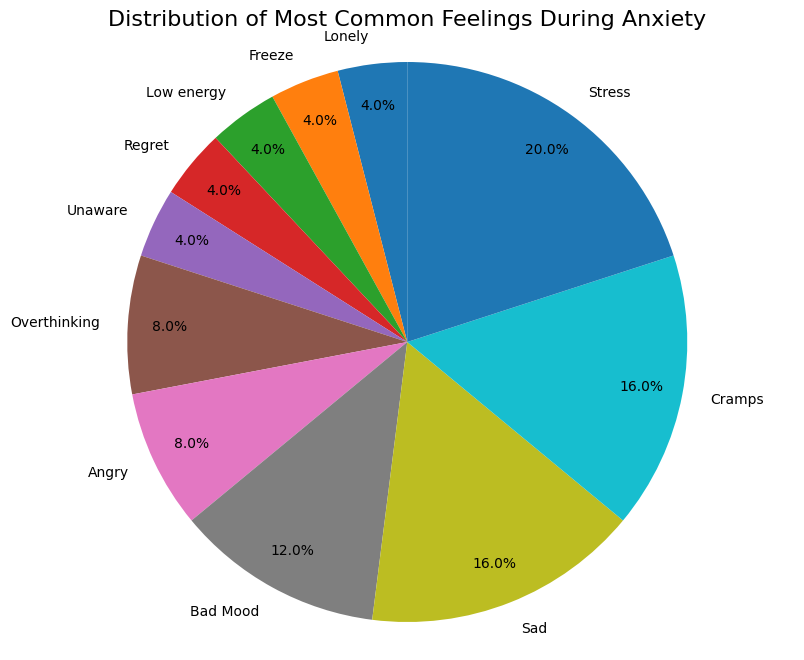

In [23]:
feelings_count={
    "Stress":5,
    "Sad":4,
    "Cramps":4,
    "Bad Mood": 3,
    "Overthinking":2,
    "Angry":2,
    "Lonely":1,
    "Freeze":1,
    "Regret":1,
    "Low energy":1,
    "Unaware":1
}

import pandas as pd
import matplotlib.pyplot as plt

s=pd.Series(feelings_count).sort_values()

plt.figure(figsize=(10, 8))
s.plot(
    kind="pie",
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)
plt.title("Distribution of Most Common Feelings During Anxiety", fontsize=16)
plt.ylabel("")
plt.xlabel("")
plt.axis('equal')
plt.show()

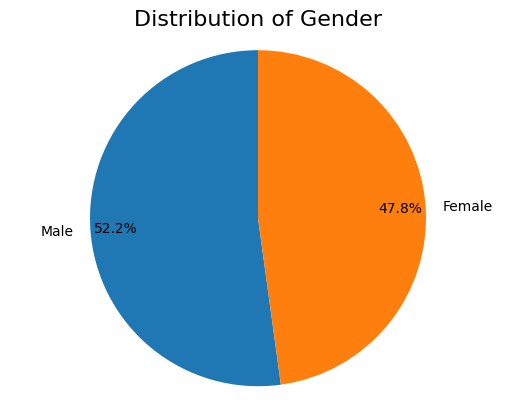

In [24]:
df["Gender"].value_counts().plot(kind="pie",autopct='%1.1f%%',startangle=90,pctdistance=0.85)
plt.title("Distribution of Gender", fontsize=16)
plt.ylabel("")
plt.xlabel("")
plt.axis('equal')
plt.show()

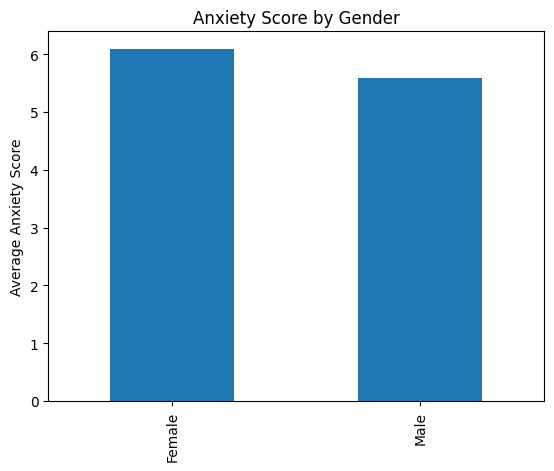

In [25]:
df.groupby("Gender")["Anxiety Score (1-10)"].mean().plot(kind="bar")
plt.title("Anxiety Score by Gender")
plt.xlabel("")
plt.ylabel("Average Anxiety Score")
plt.show()

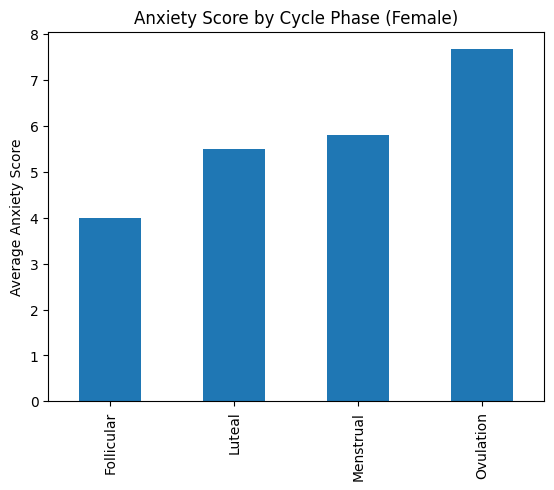

In [26]:
female_df=df[df["Gender"]=="Female"]
female_df.groupby("Cycle Phase")["Anxiety Score (1-10)"].mean().plot(kind="bar")
plt.title("Anxiety Score by Cycle Phase (Female)")
plt.xlabel("")
plt.ylabel("Average Anxiety Score")
plt.show()

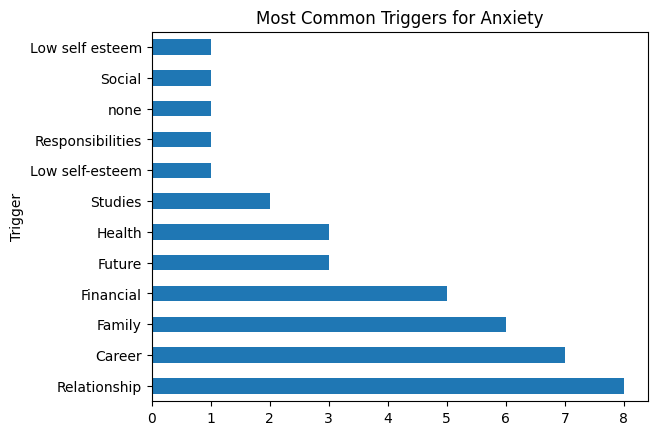

In [29]:
trigger_counts.plot(kind="barh")
plt.title("Most Common Triggers for Anxiety")
plt.xlabel("")
plt.ylabel("Trigger")
plt.show()

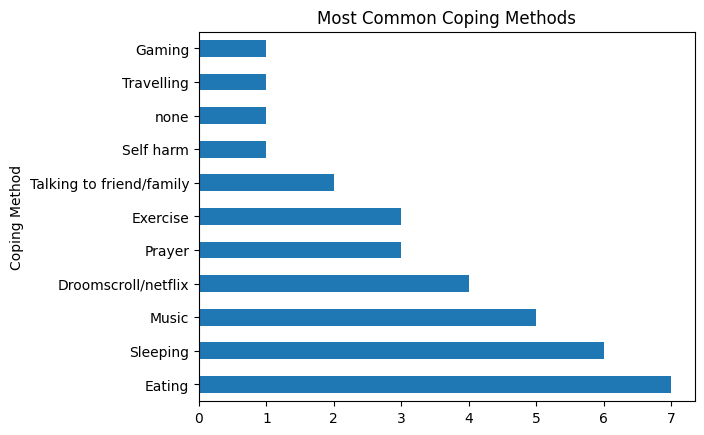

In [31]:
copings_counts.plot(kind="barh")
plt.title("Most Common Coping Methods")
plt.xlabel("")
plt.ylabel("Coping Method")
plt.show()

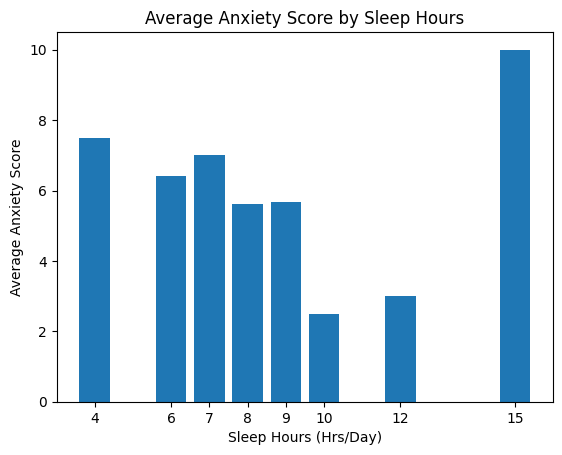

In [36]:
avg_anxiety_by_sleep = df.groupby("Sleep Hrs/Day")["Anxiety Score (1-10)"].mean().reset_index()

plt.bar(avg_anxiety_by_sleep["Sleep Hrs/Day"], avg_anxiety_by_sleep["Anxiety Score (1-10)"])
plt.title("Average Anxiety Score by Sleep Hours")
plt.xlabel("Sleep Hours (Hrs/Day)")
plt.ylabel("Average Anxiety Score")
plt.xticks(avg_anxiety_by_sleep["Sleep Hrs/Day"]) # Ensure all sleep hours are shown on x-axis
plt.show()

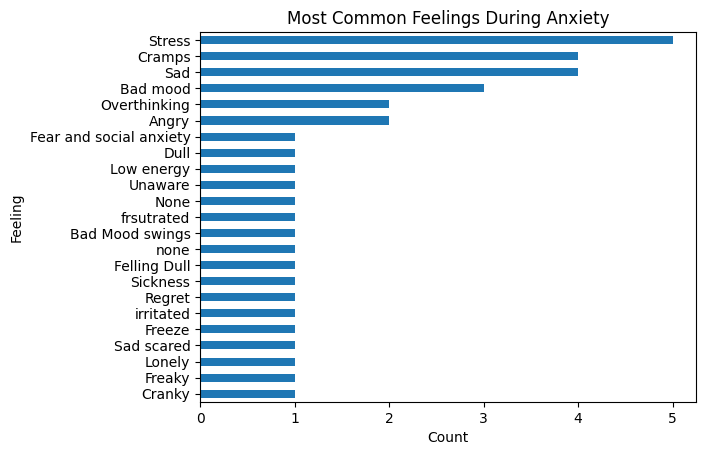

In [38]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

all_feelings_extracted = []
for _, row in df.iterrows():
  feelings=str(row["Symptoms during anxious phase"]).split(",")
  for feeling in feelings:
    feeling=feeling.strip()
    if feeling:
      all_feelings_extracted.append(feeling)

feeling_counts = pd.Series(Counter(all_feelings_extracted)).sort_values(ascending=True) # Sort ascending for barh plots to have largest at top

feeling_counts.plot(kind="barh")
plt.title("Most Common Feelings During Anxiety")
plt.xlabel("Count")
plt.ylabel("Feeling")
plt.show()